# Rozwiązanie zadania
Aby wyznaczyć wartości kroku $h$, dla których jawna metoda Eulera jest stabilna dla danego układu równań różniczkowych, musimy wyznaczyć wartości własne macierzy tego układu i podstawić je do warunku stabilności metody.

## Krok 1: Zapisanie układu w postaci macierzowej
Nasz układ równań to:$$y_1' = -2y_1 + y_2$$
$$y_2' = -y_1 - 2y_2$$
Możemy go zapisać w postaci wektorowej $\mathbf{y}' = A\mathbf{y}$, gdzie macierz układu $A$ ma postać:$$A = \begin{pmatrix} -2 & 1 \\ -1 & -2 \end{pmatrix}$$

## Krok 2: Wyznaczenie wartości własnych macierzy $A$
Wartości własne $\lambda$ znajdujemy rozwiązując równanie charakterystyczne $\det(A - \lambda I) = 0$:$$\det \begin{pmatrix} -2 - \lambda & 1 \\ -1 & -2 - \lambda \end{pmatrix} = 0$$
$$(-2 - \lambda)(-2 - \lambda) - (-1)(1) = 0$$
$$(\lambda + 2)^2 + 1 = 0$$
$$(\lambda + 2)^2 = -1$$
Z tego równania otrzymujemy dwie zespolone sprzężone wartości własne:$$\lambda_1 = -2 + i$$
$$\lambda_2 = -2 - i$$

## Krok 3: Warunek stabilności jawnej metody Eulera
Dla równania postaci $\mathbf{y}' = A\mathbf{y}$, jawna metoda Eulera jest zdefiniowana jako $\mathbf{y}_{n+1} = \mathbf{y}_n + hA\mathbf{y}_n = (I + hA)\mathbf{y}_n$.
Aby metoda była asymptotycznie stabilna, dla każdej wartości własnej $\lambda$ macierzy $A$ musi być spełniony warunek:$$|1 + h\lambda| < 1$$
Ponieważ nasze wartości własne są sprzężone, ich moduły po podstawieniu do wzoru będą identyczne. Podstawmy $\lambda_1 = -2 + i$:$$|1 + h(-2 + i)| < 1$$
$$|1 - 2h + hi| < 1$$
$$|(1 - 2h) + ih| < 1$$
Teraz obliczamy moduł tej liczby zespolonej (część rzeczywista to $1-2h$, a urojona to $h$):$$\sqrt{(1 - 2h)^2 + h^2} < 1$$
Podnosimy obie strony nierówności do kwadratu:$$(1 - 2h)^2 + h^2 < 1$$
$$1 - 4h + 4h^2 + h^2 < 1$$
$$5h^2 - 4h < 0$$
$$h(5h - 4) < 0$$

## Krok 4: Wyznaczenie dopuszczalnego kroku $h$
Rozwiązujemy otrzymaną nierówność kwadratową ze względu na $h$. Miejsca zerowe to $h=0$ oraz $h=\frac{4}{5}$. Parabola ma ramiona skierowane w górę, więc wartości ujemne przyjmuje między miejscami zerowymi. Dodatkowo krok całkowania z definicji musi być liczbą dodatnią:$h > 0$
$5h - 4 < 0 \implies h < \frac{4}{5} = 0.8$

# Odpowiedź
Jawna metoda Eulera jest stabilna dla tego układu równań, gdy krok całkowania $h$ spełnia warunek:$$h \in (0, 0.8)$$

In [131]:
import numpy as np
import matplotlib.pyplot as plt

In [132]:
h = 0.2
t_end = 5.0

y1_0 = 1.0
y2_0 = 0.0

In [133]:
# t=0: y1(0)=C1 -> C1=1, y2(0)=C -> C=0
C = y2_0
C1 = y1_0

In [134]:
t_num = np.arange(0, t_end + h, h)
y1_num = np.zeros(len(t_num))
y2_num = np.zeros(len(t_num))

y1_num[0] = y1_0
y2_num[0] = y2_0

for i in range(1, len(t_num)):
    # Derivatives
    dy1 = -2 * y1_num[i - 1] + y2_num[i - 1]
    dy2 = -y1_num[i - 1] - 2 * y2_num[i - 1]

    # Euler step
    y1_num[i] = y1_num[i - 1] + h * dy1
    y2_num[i] = y2_num[i - 1] + h * dy2

In [135]:
t_exact = np.linspace(0, t_end, 500)

y1_exact = (C * np.sin(t_exact) + C1 * np.cos(t_exact)) / np.exp(2 * t_exact)
y2_exact = (C * np.cos(t_exact) - C1 * np.sin(t_exact)) / np.exp(2 * t_exact)

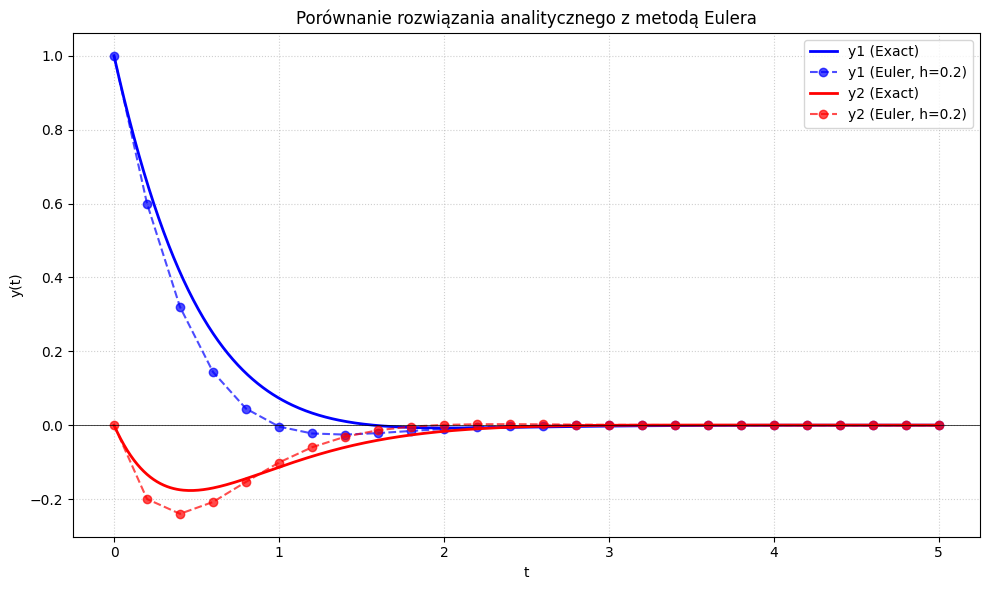

In [136]:
plt.figure(figsize=(10, 6))

plt.plot(t_exact, y1_exact, "b-", linewidth=2, label="y1 (Exact)")
plt.plot(t_num, y1_num, "bo--", alpha=0.7, label=f"y1 (Euler, h={h})")
plt.plot(t_exact, y2_exact, "r-", linewidth=2, label="y2 (Exact)")
plt.plot(t_num, y2_num, "ro--", alpha=0.7, label=f"y2 (Euler, h={h})")

plt.title("Porównanie rozwiązania analitycznego z metodą Eulera")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.axhline(0, color="black", linewidth=0.5)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()
